In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/modeling_dataset_v1.csv")

print(df.shape)
df['habitable'].value_counts()

(1859, 9)


habitable
0    1849
1      10
Name: count, dtype: int64

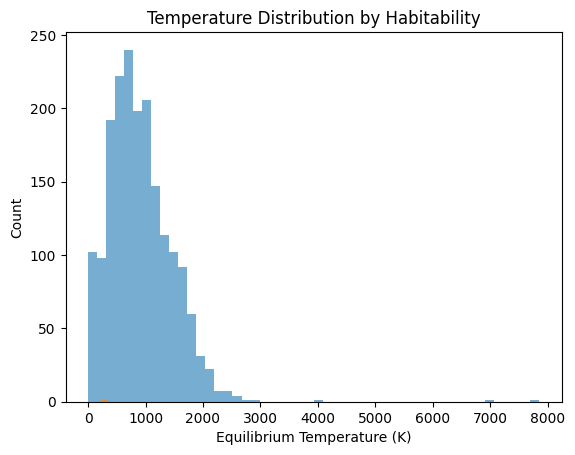

In [2]:
plt.figure()
plt.hist(df[df['habitable']==0]['teq_recalc'], bins=50, alpha=0.6)
plt.hist(df[df['habitable']==1]['teq_recalc'], bins=20, alpha=0.8)
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Count")
plt.title("Temperature Distribution by Habitability")
plt.show()

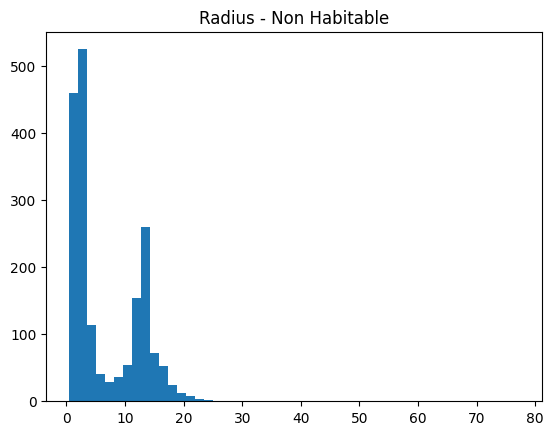

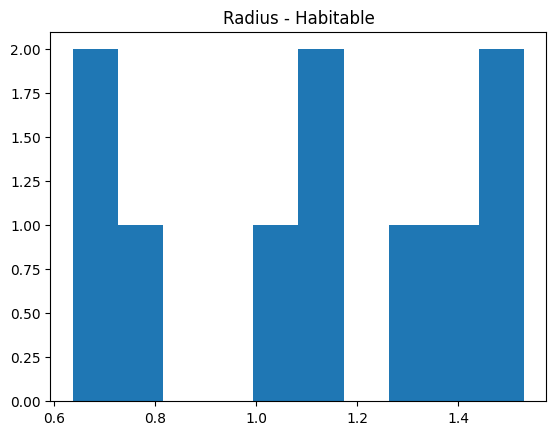

In [3]:
plt.figure()
plt.hist(df[df['habitable']==0]['pl_rade'], bins=50)
plt.title("Radius - Non Habitable")
plt.show()

plt.figure()
plt.hist(df[df['habitable']==1]['pl_rade'], bins=10)
plt.title("Radius - Habitable")
plt.show()

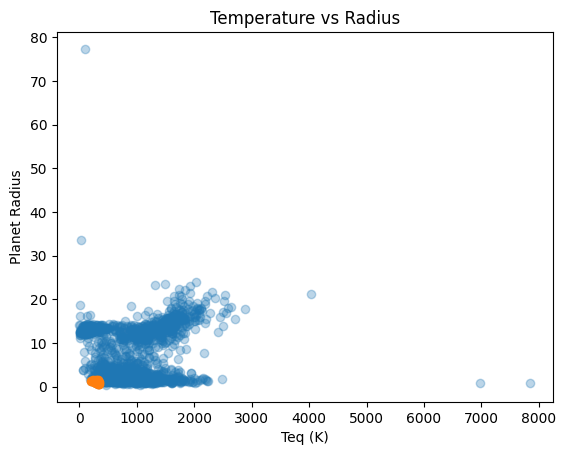

In [4]:
plt.figure()
plt.scatter(
    df['teq_recalc'],
    df['pl_rade'],
    alpha=0.3
)

plt.scatter(
    df[df['habitable']==1]['teq_recalc'],
    df[df['habitable']==1]['pl_rade'],
)

plt.xlabel("Teq (K)")
plt.ylabel("Planet Radius")
plt.title("Temperature vs Radius")
plt.show()

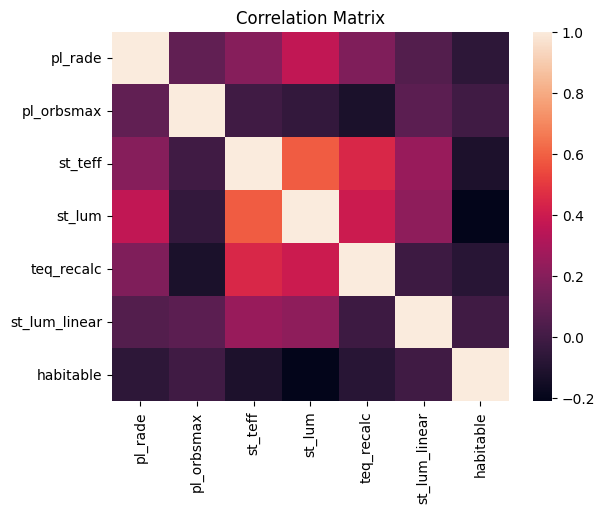

In [5]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Matrix")
plt.show()

In [6]:
# Total samples
total = len(df)

# Condition 1: Small radius
n_small_radius = (df["pl_rade"] <= 1.6).sum()

# Condition 2: Temperature band
n_temp_band = ((df["teq_recalc"] >= 200) & (df["teq_recalc"] <= 350)).sum()

# Condition 3: Both conditions
n_both = (
    (df["pl_rade"] <= 1.6) &
    (df["teq_recalc"] >= 200) &
    (df["teq_recalc"] <= 350)
).sum()

print(f"Total planets: {total}")
print(f"Radius ≤ 1.6: {n_small_radius} ({n_small_radius/total:.3%})")
print(f"200 ≤ Teq ≤ 350: {n_temp_band} ({n_temp_band/total:.3%})")
print(f"Both conditions: {n_both} ({n_both/total:.3%})")

Total planets: 1859
Radius ≤ 1.6: 337 (18.128%)
200 ≤ Teq ≤ 350: 106 (5.702%)
Both conditions: 10 (0.538%)


In [8]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Group by target and compute mean
class_summary = numeric_df.groupby(df["habitable"]).mean()

class_summary.T

habitable,0,1
pl_rade,6.554889,1.115400
pl_orbsmax,5.352514,0.136706
st_teff,5455.658815,3264.400000
st_lum,-0.111499,-2.252852
teq_recalc,915.574919,285.561606
st_lum_linear,8.944513,0.022867


In [9]:
# Calculate effect size (Cohen's d)
effect_sizes = {}

for col in numeric_df.columns:
    if col != "habitable":
        mean0 = numeric_df[df["habitable"] == 0][col].mean()
        mean1 = numeric_df[df["habitable"] == 1][col].mean()
        std0 = numeric_df[df["habitable"] == 0][col].std()
        std1 = numeric_df[df["habitable"] == 1][col].std()
        
        pooled_std = np.sqrt((std0**2 + std1**2) / 2)
        effect_sizes[col] = (mean1 - mean0) / pooled_std

effect_sizes

{'pl_rade': np.float64(-1.3076020769903947),
 'pl_orbsmax': np.float64(-0.10908936547973384),
 'st_teff': np.float64(-2.141119683620113),
 'st_lum': np.float64(-2.7587831942258507),
 'teq_recalc': np.float64(-1.5913241020181623),
 'st_lum_linear': np.float64(-0.08053364210239931)}

In [10]:
numeric_df.skew()

pl_rade           1.586140
pl_orbsmax       20.007863
st_teff           9.056625
st_lum           -0.477942
teq_recalc        2.214998
st_lum_linear    36.171729
habitable        13.535176
dtype: float64